# HealthGuard Insurance: Medical Charges Analysis and Pricing Models

EECE 6544: Introduction to Machine Learning and Pattern Recognition, Summer 2026, MiniProject #02

Stakeholder: Ms. Sarah Nabil, Head of Pricing, HealthGuard Insurance

HealthGuard currently prices its plans using outdated actuarial tables. Management believes the company is underpricing high risk customers (and losing money on them) while overpricing low risk customers (who leave for cheaper competitors). In this notebook we work through the three requirements given by the Head of Pricing:

| # | Requirement | Task | Section |
|---|---|---|---|
| 1 | "Understand our customers first" | Exploratory data analysis with at least 5 visuals | 3 and 4 |
| 2 | "Predict the medical charges" | Regression, 7 model families compared on MAE, MSE, RMSE and R2 | 5 and 6 |
| 3 | "Flag the expensive customers" | Binary classification, expensive means charges above the median | 7 |

Dataset: [Medical Cost Personal Datasets (Kaggle)](https://www.kaggle.com/datasets/mirichoi0218/insurance), 1,338 customer records with `age`, `sex`, `bmi`, `children`, `smoker`, `region` and `charges` (the annual medical cost billed to the customer, in USD).

A note on reproducibility: the raw dataframe is never modified (all cleaning happens on a copy), every random operation uses `random_state = 42`, and the cleaned data is written to its own file (`data/insurance_clean.csv`) so raw and clean data stay separate.

## 1. Setup

Imports, a fixed random seed, and one consistent chart style. We use the same two colors on every chart: blue for non-smokers and red for smokers. Keeping the colors fixed makes the whole set of figures easier to read.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.svm import SVR, SVC
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             root_mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix)

RANDOM_STATE = 42

# Chart colors (colorblind-safe). Blue = non-smoker, red = smoker, on every chart.
BLUE, GREEN, MAGENTA, YELLOW = "#2a78d6", "#008300", "#e87ba4", "#eda100"
AQUA, ORANGE, VIOLET, RED = "#1baf7a", "#eb6834", "#4a3aa7", "#e34948"
CATEGORICAL = [BLUE, GREEN, MAGENTA, YELLOW, AQUA, ORANGE, VIOLET, RED]
SMOKER_COLORS = {"no": BLUE, "yes": RED}
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
SURFACE = "#fcfcfb"
DIVERGING = LinearSegmentedColormap.from_list("brand_div", [BLUE, "#f0efec", RED])
SEQ_BLUES = LinearSegmentedColormap.from_list("brand_blues", ["#cde2fb", "#3987e5", "#0d366b"])

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2,
    "axes.titlecolor": INK, "axes.titleweight": "bold", "axes.titlesize": 11.5,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
    "figure.dpi": 110,
})

CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

def save_show(fig, name):
    # Save a copy for the report, then display inline
    fig.savefig(CHARTS / name, dpi=150, bbox_inches="tight")
    plt.show()

print(f"pandas {pd.__version__} | numpy {np.__version__} | scikit-learn {sklearn.__version__} | seaborn {sns.__version__}")

pandas 3.0.1 | numpy 2.4.2 | scikit-learn 1.8.0 | seaborn 0.13.2


## 2. Loading and profiling the data

The file is read with `encoding="utf-8"` stated explicitly. We then use `head`, `shape`, `info`, `describe` and `value_counts` to get a first look at the size, structure and quality of the data before changing anything.

In [2]:
df_raw = pd.read_csv("data/insurance.csv", encoding="utf-8")
print(f"Rows: {df_raw.shape[0]:,} | Columns: {df_raw.shape[1]}")
df_raw.head(10)

Rows: 1,338 | Columns: 7


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [4]:
# Numeric profile
df_raw.describe().round(2)

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


In [5]:
# Categorical profile
df_raw.describe(include=["object", "str"])

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [6]:
for col in ["sex", "smoker", "region", "children"]:
    print(df_raw[col].value_counts(), end="\n\n")
print("Smoker share:")
print(df_raw["smoker"].value_counts(normalize=True).round(3))

sex
male      676
female    662
Name: count, dtype: int64

smoker
no     1064
yes     274
Name: count, dtype: int64

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

Smoker share:
smoker
no     0.795
yes    0.205
Name: proportion, dtype: float64


**What we see so far**

- 1,338 rows and 7 columns. `info()` shows 1,338 non-null values in every column, so nothing is obviously missing.
- The types look right: `age` and `children` are integers, `bmi` and `charges` are floats, and `sex`, `smoker` and `region` are text.
- The categories already look clean (exactly 2 sexes, 2 smoker values and 4 regions, no visible typos). We still standardize the text later as a precaution.
- `charges` runs from about \$1,122 to \$63,770 and the mean is well above the median, so the distribution is clearly right skewed. We will look at this in the EDA.
- About 20% of the customers smoke. Regions and sexes are roughly balanced.

## 3. Data cleaning

We treat the raw dataframe `df_raw` as read-only. Every cleaning step happens on a copy called `df`, and the cleaned result is saved to a separate file at the end. Each decision is explained as we go, and a summary table closes the section.

In [7]:
# Work on a copy - the raw dataframe stays untouched (immutability principle)
df = df_raw.copy()

### 3.1 Missing values

In [8]:
missing = df.isna().sum().to_frame("missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(2)
missing

,missing_count,missing_pct
age,0,0.0
sex,0,0.0
bmi,0,0.0
children,0,0.0
smoker,0,0.0
region,0,0.0
charges,0,0.0


**Decision:** there are no missing values, so no imputation is needed. If there had been any, the plan was median imputation for the numeric columns (the median is robust to the skew in this data), mode for the categorical ones, and dropping any row with a missing value in `charges`, because it makes no sense to impute the value we are trying to predict.

### 3.2 Duplicate rows

In [9]:
print(f"Exact duplicate rows: {df.duplicated().sum()}")
df[df.duplicated(keep=False)]

Exact duplicate rows: 1


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [10]:
df = df.drop_duplicates(keep="first").reset_index(drop=True)
print(f"Rows after dropping duplicates: {len(df):,} (was {len(df_raw):,})")

Rows after dropping duplicates: 1,337 (was 1,338)


**Decision:** there is one exact duplicate, a 19 year old male non-smoker from the northwest with charges of \$1,639.56. We drop it and keep the first occurrence. The data has no customer ID, so we cannot confirm these are two different people, and keeping an identical row just double counts one observation in every model. This leaves **1,337 rows**.

### 3.3 Inconsistent categories (replacing and standardizing text)

In [11]:
# Standardize text columns: strip whitespace, lowercase everything
for col in df.select_dtypes(include=["str", "object"]).columns:
    df[col] = df[col].str.strip().str.lower()

{col: sorted(df[col].unique()) for col in ["sex", "smoker", "region"]}

{'sex': ['female', 'male'],
 'smoker': ['no', 'yes'],
 'region': ['northeast', 'northwest', 'southeast', 'southwest']}

**Decision:** the categories were already consistent, but we keep the strip and lowercase step anyway. It costs nothing and protects the notebook if a future version of the file contains values like `"Male "` or `"YES"`.

### 3.4 Invalid values (range and sanity checks)

In [12]:
checks = {
    "age within 18-64":                  df["age"].between(18, 64).all(),
    "bmi plausible (10-70)":             df["bmi"].between(10, 70).all(),
    "children non-negative (0-5 seen)":  df["children"].between(0, 5).all(),
    "charges strictly positive":         (df["charges"] > 0).all(),
}
for rule, ok in checks.items():
    print(f"{'PASS' if ok else 'FAIL'}  {rule}")
print(f"\nRanges -> age: {df['age'].min()}-{df['age'].max()} | "
      f"bmi: {df['bmi'].min()}-{df['bmi'].max()} | "
      f"charges: {df['charges'].min():,.2f}-{df['charges'].max():,.2f}")

PASS  age within 18-64
PASS  bmi plausible (10-70)
PASS  children non-negative (0-5 seen)
PASS  charges strictly positive

Ranges -> age: 18-64 | bmi: 15.96-53.13 | charges: 1,121.87-63,770.43


**Decision:** every value passes its sanity check, so nothing is dropped or repaired. In particular we keep the very large charges (up to \$63,770). They are not data errors. The EDA below shows they belong almost entirely to older or obese smokers, which are exactly the customers HealthGuard is currently mispricing, so removing them would defeat the purpose of the project.

### 3.5 Data types

In [13]:
df = df.astype({"sex": "category", "smoker": "category", "region": "category"})
df.dtypes

age            int64
sex         category
bmi          float64
children       int64
smoker      category
region      category
charges      float64
dtype: object

### 3.6 Feature engineering (creating columns with `cut` and boolean logic)

Two ordinal helper columns for the EDA, plus a flag that the EDA will justify:

In [14]:
df["bmi_category"] = pd.cut(df["bmi"], bins=[0, 18.5, 25, 30, np.inf],
                            labels=["underweight", "normal", "overweight", "obese"])
df["age_group"] = pd.cut(df["age"], bins=[17, 29, 44, 64],
                         labels=["18-29", "30-44", "45-64"])
df["obese_smoker"] = ((df["bmi"] >= 30) & (df["smoker"] == "yes")).map({True: "yes", False: "no"})
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_category,age_group,obese_smoker
0,19,female,27.900,0,yes,southwest,16884.92400,overweight,18-29,no
1,18,male,33.770,1,no,southeast,1725.55230,obese,18-29,no
2,28,male,33.000,3,no,southeast,4449.46200,obese,18-29,no
3,33,male,22.705,0,no,northwest,21984.47061,normal,30-44,no
4,32,male,28.880,0,no,northwest,3866.85520,overweight,30-44,no


### 3.7 More of the wrangling toolkit: selecting, filtering, sorting, grouping, merging, concatenating, applying, renaming

In [15]:
# Sorting + column selection: the ten most expensive customers on the book
df.sort_values("charges", ascending=False)[["age", "sex", "bmi", "smoker", "region", "charges"]].head(10)

,age,sex,bmi,smoker,region,charges
543,54,female,47.410,yes,southeast,63770.42801
1299,45,male,30.360,yes,southeast,62592.87309
1229,52,male,34.485,yes,northwest,60021.39897
577,31,female,38.095,yes,northeast,58571.07448
818,33,female,35.530,yes,northwest,55135.40209
1145,60,male,32.800,yes,southwest,52590.82939
34,28,male,36.400,yes,southwest,51194.55914
1240,64,male,36.960,yes,southeast,49577.66240
1061,59,male,41.140,yes,southeast,48970.24760
488,44,female,38.060,yes,southeast,48885.13561


In [16]:
# Filtering: the obese-smoker segment (the EDA will show it is by far the most expensive)
segment = df[(df["smoker"] == "yes") & (df["bmi"] >= 30)]
print(f"Obese smokers: {len(segment)} customers ({len(segment) / len(df):.1%} of the book) | "
      f"mean charges ${segment['charges'].mean():,.0f} vs ${df['charges'].mean():,.0f} overall")

Obese smokers: 145 customers (10.8% of the book) | mean charges $41,558 vs $13,279 overall


In [17]:
# Grouping + aggregating, then MERGING the group statistic back onto each customer
region_avg = (df.groupby("region", observed=True)["charges"].mean()
                .round(0).rename("region_avg_charges").reset_index())
df_enriched = df.merge(region_avg, on="region", how="left")
df_enriched["vs_region_avg"] = (df_enriched["charges"] - df_enriched["region_avg_charges"]).round(0)
df_enriched[["region", "charges", "region_avg_charges", "vs_region_avg"]].head()

,region,charges,region_avg_charges,vs_region_avg
0,southwest,16884.92400,12347.0,4538.0
1,southeast,1725.55230,14735.0,-13009.0
2,southeast,4449.46200,14735.0,-10286.0
3,northwest,21984.47061,12451.0,9533.0
4,northwest,3866.85520,12451.0,-8584.0


In [18]:
# Concatenating: charge profiles of smokers vs non-smokers side by side
profile = pd.concat({"smokers": df.loc[df["smoker"] == "yes", "charges"].describe(),
                     "non-smokers": df.loc[df["smoker"] == "no", "charges"].describe()},
                    axis=1).round(0)
profile

,smokers,non-smokers
count,274.0,1063.0
mean,32050.0,8441.0
std,11542.0,5993.0
min,12829.0,1122.0
25%,20826.0,3989.0
50%,34456.0,7346.0
75%,41019.0,11363.0
max,63770.0,36911.0


In [19]:
# Applying a function row-wise: a risk segment label the pricing team can use directly
def risk_label(row):
    if row["smoker"] == "yes" and row["bmi"] >= 30:
        return "very high"
    if row["smoker"] == "yes":
        return "high"
    if row["bmi"] >= 30 or row["age"] >= 50:
        return "moderate"
    return "standard"

df["risk_label"] = df.apply(risk_label, axis=1)
df.groupby("risk_label", observed=True)["charges"].agg(["count", "mean"]).round(0).sort_values("mean", ascending=False)

,count,mean
risk_label,,
very high,145,41558.0
high,129,21363.0
moderate,685,9648.0
standard,378,6253.0


The segments built with `apply` line up with the EDA story: the "very high" group (obese smokers, 145 customers) averages \$41,558, "high" (other smokers) \$21,363, "moderate" \$9,648 and "standard" \$6,253. This gives the pricing team a simple four tier view of the book.

In [20]:
# Renaming: a stakeholder-friendly view (the analysis itself keeps the short names)
df.rename(columns={"bmi": "body_mass_index", "charges": "annual_medical_charges"}).head(3)

,age,sex,body_mass_index,children,smoker,region,annual_medical_charges,bmi_category,age_group,obese_smoker,risk_label
0,19,female,27.90,0,yes,southwest,16884.9240,overweight,18-29,no,high
1,18,male,33.77,1,no,southeast,1725.5523,obese,18-29,no,moderate
2,28,male,33.00,3,no,southeast,4449.4620,obese,18-29,no,moderate


### 3.8 Save the cleaned dataset (raw and clean kept separate)

In [21]:
df.to_csv("data/insurance_clean.csv", index=False)
print(f"Saved data/insurance_clean.csv - {df.shape[0]:,} rows x {df.shape[1]} columns")

Saved data/insurance_clean.csv - 1,337 rows x 11 columns


### Cleaning decisions, summarized

| Issue | Finding | Decision | Rationale |
|---|---|---|---|
| Missing values | 0 in all 7 columns | Nothing to impute | Strategy documented anyway (median/mode, and never impute the target) |
| Duplicate rows | 1 exact duplicate | Drop it, keep the first | No ID to tell two customers apart, and an identical row double counts one observation |
| Inconsistent categories | None found | Strip + lowercase anyway | Cheap protection against future data refreshes |
| Invalid values | None (all ranges plausible) | Keep all rows | age 18-64, BMI 15.96-53.13, children 0-5, charges all positive |
| Extreme charges | Right skew, max \$63,770 | Keep them, they are not errors | The high costs sit with older/obese smokers, the exact customers we need to price correctly |
| Raw vs clean | | `df_raw` never modified; clean copy saved to its own CSV | Anyone can re-derive `insurance_clean.csv` from the raw file |

## 4. Exploratory data analysis: "Understand our customers first" (Requirement 1)

Seven visuals the stakeholder can take to the board, each followed by a short interpretation, and a summary at the end of the section.

### 4.1 How are annual charges distributed?

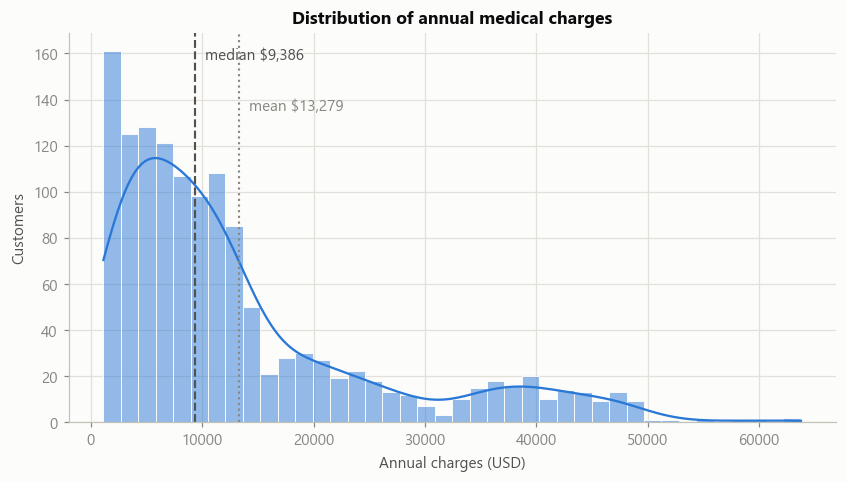

Skewness: 1.52


In [22]:
fig, ax = plt.subplots(figsize=(9, 4.6))
sns.histplot(df["charges"], bins=40, kde=True, color=BLUE, edgecolor=SURFACE, linewidth=0.6, ax=ax)
med, mean = df["charges"].median(), df["charges"].mean()
ax.axvline(med, color=INK2, lw=1.4, ls="--")
ax.axvline(mean, color=MUTED, lw=1.4, ls=":")
ymax = ax.get_ylim()[1]
ax.text(med + 900, ymax * 0.93, rf"median \${med:,.0f}", color=INK2, fontsize=10)
ax.text(mean + 900, ymax * 0.80, rf"mean \${mean:,.0f}", color=MUTED, fontsize=10)
ax.set_title("Distribution of annual medical charges")
ax.set_xlabel("Annual charges (USD)")
ax.set_ylabel("Customers")
save_show(fig, "charges_distribution.png")
print(f"Skewness: {df['charges'].skew():.2f}")

Half the customers cost less than \$9,386 a year, but the tail runs past \$60,000 (skewness 1.52) and the mean (\$13,279) sits about 41% above the median. A flat, table based price is going to misprice that tail.

### 4.2 The effect of smoking

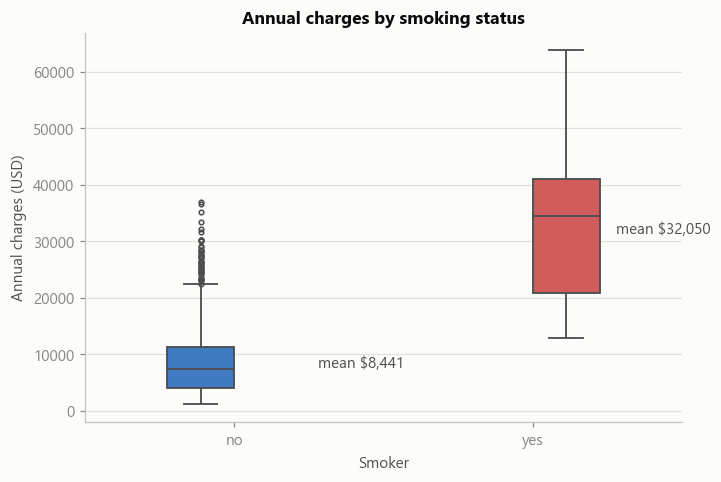

,count,mean,median,std
smoker,,,,
no,1063,8441.0,7346.0,5993.0
yes,274,32050.0,34456.0,11542.0


In [23]:
fig, ax = plt.subplots(figsize=(7, 4.6))
sns.boxplot(data=df, x="smoker", y="charges", hue="smoker", order=["no", "yes"],
            hue_order=["no", "yes"], palette=SMOKER_COLORS, width=0.45,
            legend=False, linewidth=1.2, fliersize=3, ax=ax)
for i, grp in enumerate(["no", "yes"]):
    m = df.loc[df["smoker"] == grp, "charges"].mean()
    ax.text(i + 0.28, m, rf"mean \${m:,.0f}", va="center", fontsize=10, color=INK2)
ax.set_title("Annual charges by smoking status")
ax.set_xlabel("Smoker")
ax.set_ylabel("Annual charges (USD)")
save_show(fig, "charges_by_smoker.png")

df.groupby("smoker", observed=True)["charges"].agg(["count", "mean", "median", "std"]).round(0)

Smokers make up about 20% of the customers but average **\$32,050** a year against **\$8,441** for non-smokers, roughly a 3.8x gap. The two distributions barely overlap: a typical smoker costs more than most non-smokers ever will. This is the single biggest cost driver in the data.

### 4.3 BMI and smoking together

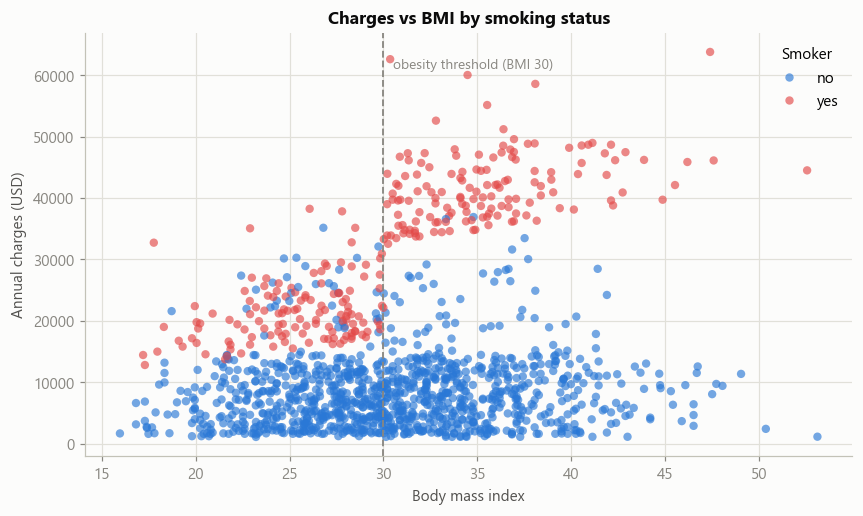

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", hue_order=["no", "yes"],
                palette=SMOKER_COLORS, alpha=0.65, s=30, edgecolor="none", ax=ax)
ax.axvline(30, color=MUTED, lw=1.2, ls="--")
ax.text(30.5, 61000, "obesity threshold (BMI 30)", color=MUTED, fontsize=9)
ax.set_title("Charges vs BMI by smoking status")
ax.set_xlabel("Body mass index")
ax.set_ylabel("Annual charges (USD)")
ax.legend(title="Smoker", frameon=False)
save_show(fig, "bmi_vs_charges.png")

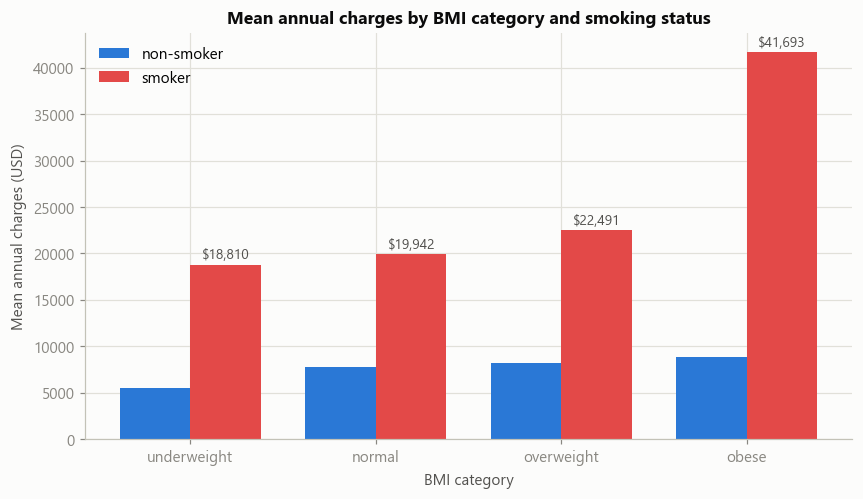

In [25]:
pivot = df.groupby(["bmi_category", "smoker"], observed=True)["charges"].mean().unstack()
x = np.arange(len(pivot.index))
w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(x - w / 2, pivot["no"], width=w, color=BLUE, label="non-smoker")
ax.bar(x + w / 2, pivot["yes"], width=w, color=RED, label="smoker")
for xi, v in zip(x + w / 2, pivot["yes"]):
    ax.text(xi, v + 600, rf"\${v:,.0f}", ha="center", fontsize=9, color=INK2)
ax.set_xticks(x, pivot.index.astype(str))
ax.set_title("Mean annual charges by BMI category and smoking status")
ax.set_xlabel("BMI category")
ax.set_ylabel("Mean annual charges (USD)")
ax.legend(frameon=False)
save_show(fig, "bmi_smoker_interaction.png")

This is the most surprising pattern in the data, and it answers the stakeholder's question directly. For non-smokers, BMI barely moves the bill (from \$5,485 for underweight up to \$8,866 for obese). For smokers the effect is huge: obese smokers average **\$41,693**, which is about 4.7 times obese non-smokers and more than double non-obese smokers. In other words the risk factors multiply rather than add, and an additive pricing table will always misprice this segment.

### 4.4 The effect of age

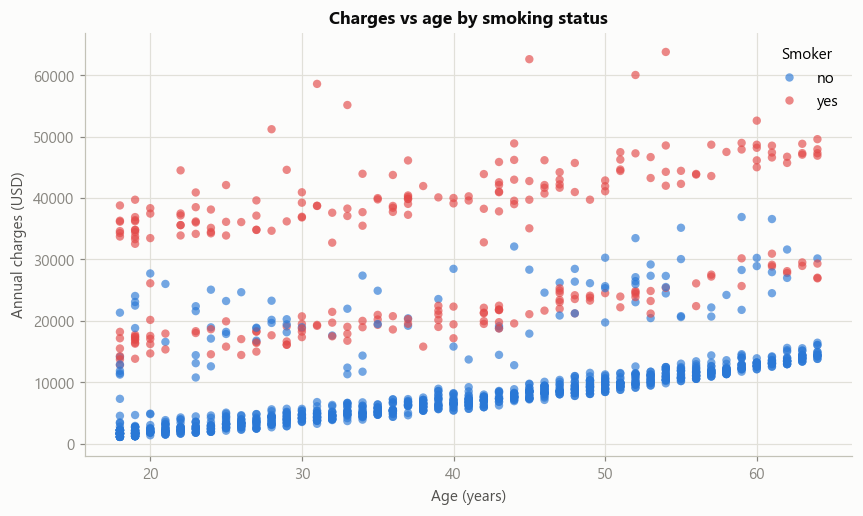

,count,mean,median
age_group,,,
18-29,416,9201.0,3220.0
30-44,392,12491.0,6798.0
45-64,529,17070.0,12029.0


In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=df, x="age", y="charges", hue="smoker", hue_order=["no", "yes"],
                palette=SMOKER_COLORS, alpha=0.65, s=30, edgecolor="none", ax=ax)
ax.set_title("Charges vs age by smoking status")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Annual charges (USD)")
ax.legend(title="Smoker", frameon=False)
save_show(fig, "age_vs_charges.png")

df.groupby("age_group", observed=True)["charges"].agg(["count", "mean", "median"]).round(0)

Costs climb steadily with age in every group (18-29: \$9,201, 30-44: \$12,491, 45-64: \$17,070 on average). The scatter also shows three roughly parallel bands: non-smokers at the bottom, smokers at the top, and a mixed band in between (high BMI non-smokers together with low BMI smokers). Age shifts everyone up at a similar rate, around \$250 to \$280 per extra year based on the regression coefficients in section 6.

### 4.5 What matters less: region, children, sex

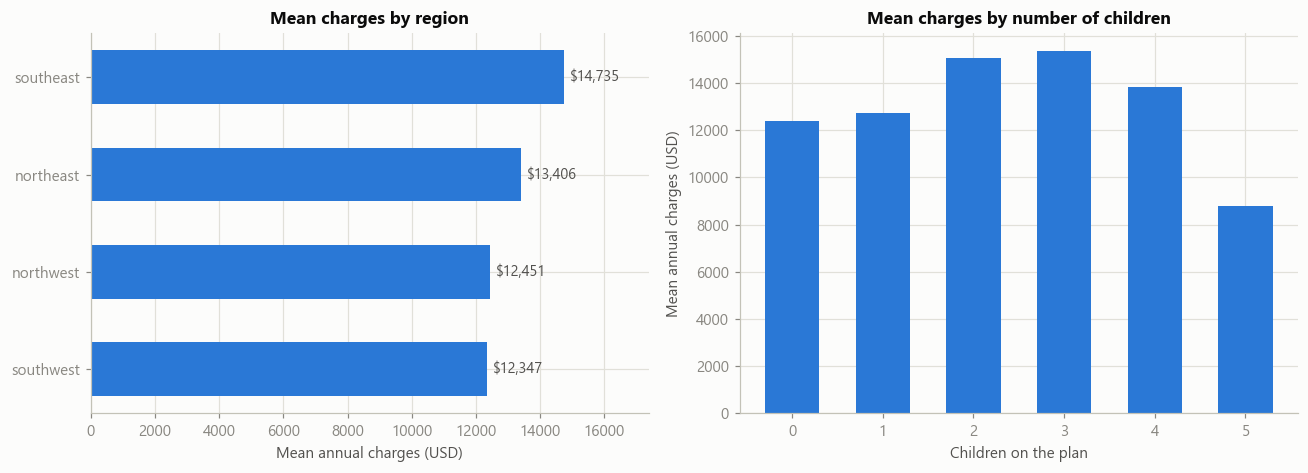

sex
female    12570.0
male      13975.0
Name: charges, dtype: float64


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
region_means = df.groupby("region", observed=True)["charges"].mean().sort_values()
axes[0].barh(region_means.index.astype(str), region_means.values, color=BLUE, height=0.55)
for i, v in enumerate(region_means.values):
    axes[0].text(v + 180, i, rf"\${v:,.0f}", va="center", fontsize=9.5, color=INK2)
axes[0].set_xlim(0, region_means.max() * 1.18)
axes[0].set_title("Mean charges by region")
axes[0].set_xlabel("Mean annual charges (USD)")

child_means = df.groupby("children", observed=True)["charges"].mean()
axes[1].bar(child_means.index.astype(str), child_means.values, color=BLUE, width=0.6)
axes[1].set_title("Mean charges by number of children")
axes[1].set_xlabel("Children on the plan")
axes[1].set_ylabel("Mean annual charges (USD)")
fig.tight_layout()
save_show(fig, "region_children.png")

print(df.groupby("sex", observed=True)["charges"].mean().round(0))

Region only spans \$12,347 (southwest) to \$14,735 (southeast), and the southeast's edge mostly reflects that it has more smokers with higher BMI rather than geography itself. Children and sex move the averages even less. These are second order factors.

### 4.6 Correlation overview

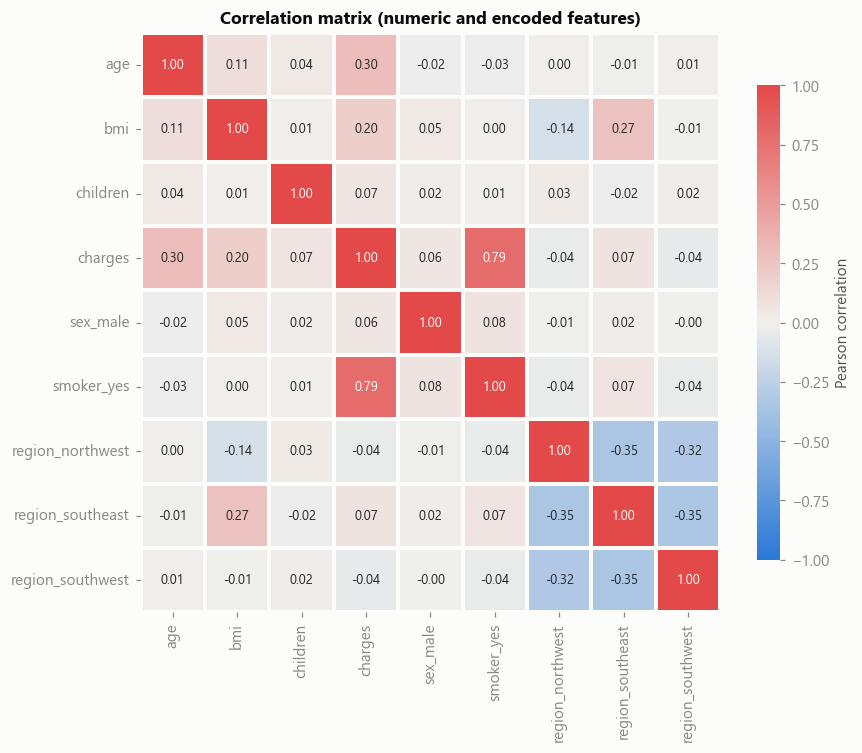

,corr with charges
smoker_yes,0.787
age,0.298
bmi,0.198
region_southeast,0.074
children,0.067
sex_male,0.058
region_southwest,-0.044
region_northwest,-0.039


In [28]:
CORE = ["age", "sex", "bmi", "children", "smoker", "region", "charges"]
corr = pd.get_dummies(df[CORE], columns=["sex", "smoker", "region"],
                      drop_first=True, dtype=int).corr()

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=DIVERGING, center=0, vmin=-1, vmax=1,
            square=True, linewidths=1.5, linecolor=SURFACE,
            cbar_kws={"shrink": 0.8, "label": "Pearson correlation"},
            annot_kws={"fontsize": 8.5}, ax=ax)
ax.grid(False)
ax.set_title("Correlation matrix (numeric and encoded features)")
save_show(fig, "correlation_heatmap.png")

corr["charges"].drop("charges").sort_values(key=abs, ascending=False).round(3).to_frame("corr with charges")

### 4.7 EDA summary for the stakeholder

What drives medical costs, in order:

1. **Smoking** (correlation 0.79). Smokers average \$32,050 against \$8,441 for non-smokers. Nothing else comes close.
2. **Age** (correlation 0.30), worth roughly \$250 to \$280 per extra year for everyone.
3. **BMI** (correlation 0.20 overall, but much stronger for smokers). The surprising pattern is the smoking and obesity interaction: obese smokers average \$41,693, about 4.7 times obese non-smokers. Risk multiplies rather than adds.
4. **Region, children and sex** barely matter (every correlation below 0.08 in absolute value). The southeast only looks pricier because it has more smokers with higher BMI.

For pricing, this means premiums should be driven mainly by smoking status, age, and BMI in combination with smoking. And because the charges distribution is so skewed, the models in the next sections should be judged on how well they price the expensive tail, since that is where the current tables lose money.

## 5. Preparing the data for modeling

- The categorical columns are one-hot encoded with `drop_first=True`, which gives `sex_male`, `smoker_yes` and three region dummies.
- The helper columns from the EDA (`bmi_category`, `age_group`, `obese_smoker`, `risk_label`) are left out on purpose. They are derived from `age`, `bmi` and `smoker`, so they would only duplicate information the models already have.
- Every regression model uses the same fixed 80/20 train/test split (`random_state=42`) so the comparison is fair. Models that need feature scaling get a `StandardScaler` inside a `Pipeline`, which means the scaler is fit on the training folds only and nothing leaks from the test set, including during cross validation.

In [29]:
df_model = pd.get_dummies(df[CORE], columns=["sex", "smoker", "region"],
                          drop_first=True, dtype=int)
X = df_model.drop(columns="charges")
y = df_model["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=RANDOM_STATE)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Features: {list(X.columns)}")

Train: 1069 rows | Test: 268 rows
Features: ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


In [30]:
reg_results = []

def evaluate_regression(name, model, X_tr=None, X_te=None):
    # Fit on the training set, report all four required metrics on the held-out test set
    X_tr = X_train if X_tr is None else X_tr
    X_te = X_test if X_te is None else X_te
    model.fit(X_tr, y_train)
    pred = model.predict(X_te)
    row = {"Model": name,
           "MAE": mean_absolute_error(y_test, pred),
           "MSE": mean_squared_error(y_test, pred),
           "RMSE": root_mean_squared_error(y_test, pred),
           "R2 (test)": r2_score(y_test, pred),
           "R2 (train)": r2_score(y_train, model.predict(X_tr))}
    reg_results.append(row)
    print(f"{name}:  MAE=${row['MAE']:,.0f}  RMSE=${row['RMSE']:,.0f}  "
          f"R2(test)={row['R2 (test)']:.3f}  R2(train)={row['R2 (train)']:.3f}")
    return model

## 6. Regression: "Predict the medical charges" (Requirement 2)

We build the seven model families the stakeholder asked for and evaluate all of them on the same held-out test set with MAE, MSE, RMSE and R2. Hyperparameters are tuned with 5-fold cross validation on the training set only.

### 6.1 Simple Linear Regression (single best predictor)

In the EDA the strongest single predictor of charges was `smoker` (correlation 0.79, far ahead of age at 0.30), so the one-feature model uses `smoker_yes`.

In [31]:
slr = evaluate_regression("Simple Linear (smoker only)", LinearRegression(),
                          X_train[["smoker_yes"]], X_test[["smoker_yes"]])
print(f"\nBaseline (non-smoker) prediction: ${slr.intercept_:,.0f}")
print(f"Smoker premium (coefficient):     +${slr.coef_[0]:,.0f}")

Simple Linear (smoker only):  MAE=$5,831  RMSE=$7,749  R2(test)=0.673  R2(train)=0.599

Baseline (non-smoker) prediction: $8,498
Smoker premium (coefficient):     +$22,637


A single question, "do you smoke", already explains about 67% of the variance on the test set. The model predicts \$8,498 for a non-smoker and adds \$22,637 for a smoker. It is a strong baseline, but it gives every smoker the same quote, so it cannot tell a 20 year old lean smoker apart from a 60 year old obese one.

### 6.2 Multiple Linear Regression (all features)

In [32]:
mlr = evaluate_regression("Multiple Linear (all features)", LinearRegression())
pd.Series(mlr.coef_, index=X.columns, name="coefficient (USD)").round(1).to_frame()

Multiple Linear (all features):  MAE=$4,177  RMSE=$5,956  R2(test)=0.807  R2(train)=0.730


,coefficient (USD)
age,248.2
bmi,318.7
children,533.0
sex_male,-101.5
smoker_yes,23077.8
region_northwest,-391.8
region_southeast,-838.9
region_southwest,-659.1


Using all the features lifts test R2 to about 0.81. The coefficients read like a price list: add \$23,078 if the customer smokes, \$248 per year of age, \$319 per BMI point and \$533 per child, while sex and region cost almost nothing. A straight line still cannot express the smoking and BMI interaction we saw in the EDA, which is what the next model is for.

### 6.3 Polynomial Regression (degrees 2 to 4) and overfitting

In [33]:
degrees = [1, 2, 3, 4]
poly_train_r2, poly_test_r2 = [], []
for d in degrees:
    pipe = Pipeline([("scale", StandardScaler()),
                     ("poly", PolynomialFeatures(degree=d, include_bias=False)),
                     ("lr", LinearRegression())])
    pipe.fit(X_train, y_train)
    poly_train_r2.append(r2_score(y_train, pipe.predict(X_train)))
    poly_test_r2.append(r2_score(y_test, pipe.predict(X_test)))
    if d >= 2:
        evaluate_regression(f"Polynomial (degree {d})", pipe)

Polynomial (degree 2):  MAE=$2,867  RMSE=$4,646  R2(test)=0.883  R2(train)=0.834
Polynomial (degree 3):  MAE=$3,049  RMSE=$4,870  R2(test)=0.871  R2(train)=0.847


Polynomial (degree 4):  MAE=$3,756  RMSE=$6,058  R2(test)=0.800  R2(train)=0.867


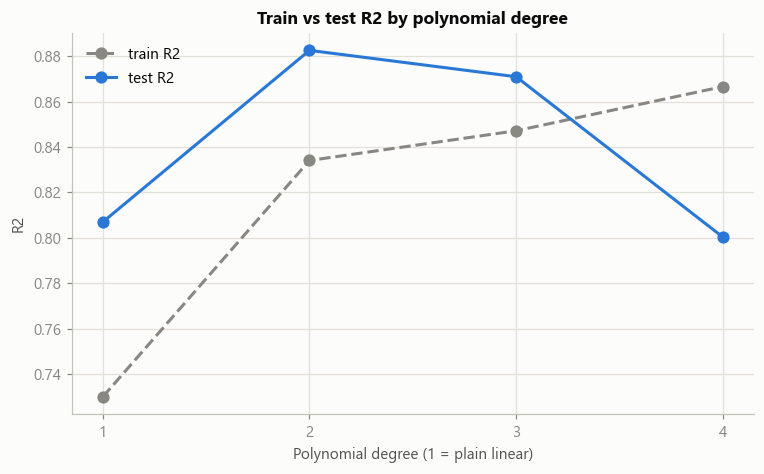

In [34]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(degrees, poly_train_r2, marker="o", ms=7, lw=2, color=MUTED, ls="--", label="train R2")
ax.plot(degrees, poly_test_r2, marker="o", ms=7, lw=2, color=BLUE, label="test R2")
ax.set_xticks(degrees)
ax.set_title("Train vs test R2 by polynomial degree")
ax.set_xlabel("Polynomial degree (1 = plain linear)")
ax.set_ylabel("R2")
ax.legend(frameon=False)
save_show(fig, "polynomial_overfitting.png")

Degree 2 adds interaction terms (most importantly `bmi` times `smoker_yes`) and pushes test R2 from 0.81 up to 0.883. After that, training R2 keeps rising (0.834, then 0.847, then 0.867) while test R2 falls (0.883, then 0.871, then 0.800). This is overfitting: the model starts memorizing training noise instead of learning structure. Degree 2 is the sweet spot for this data.

### 6.4 Ridge Regression (L2), tuned alpha

In [35]:
ridge_pipe = Pipeline([("scale", StandardScaler()), ("m", Ridge())])
ridge_grid = GridSearchCV(ridge_pipe, {"m__alpha": np.logspace(-3, 3, 25)},
                          cv=5, scoring="neg_root_mean_squared_error")
ridge_grid.fit(X_train, y_train)
alpha_r = ridge_grid.best_params_["m__alpha"]
print(f"Best alpha (5-fold CV): {alpha_r:.3g}")
evaluate_regression(f"Ridge (alpha={alpha_r:.3g})", ridge_grid.best_estimator_)

Best alpha (5-fold CV): 5.62
Ridge (alpha=5.62):  MAE=$4,191  RMSE=$5,973  R2(test)=0.806  R2(train)=0.730


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('m', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",np.float64(5.623413251903491)
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None


### 6.5 Lasso Regression (L1), tuned alpha, eliminated features

In [36]:
lasso_pipe = Pipeline([("scale", StandardScaler()), ("m", Lasso(max_iter=50000))])
lasso_grid = GridSearchCV(lasso_pipe, {"m__alpha": np.logspace(-1, 3, 25)},
                          cv=5, scoring="neg_root_mean_squared_error")
lasso_grid.fit(X_train, y_train)
alpha_l = lasso_grid.best_params_["m__alpha"]
print(f"Best alpha (5-fold CV): {alpha_l:.3g}")
evaluate_regression(f"Lasso (alpha={alpha_l:.3g})", lasso_grid.best_estimator_)

lasso_coefs = pd.Series(lasso_grid.best_estimator_.named_steps["m"].coef_,
                        index=X.columns, name="coefficient (standardized)").round(1)
eliminated = lasso_coefs[lasso_coefs == 0].index.tolist()
print(f"\nFeatures ELIMINATED by Lasso (coefficient shrunk to exactly 0): {eliminated}")
lasso_coefs.sort_values(key=abs, ascending=False).to_frame()

Best alpha (5-fold CV): 46.4
Lasso (alpha=46.4):  MAE=$4,186  RMSE=$5,988  R2(test)=0.805  R2(train)=0.730

Features ELIMINATED by Lasso (coefficient shrunk to exactly 0): ['sex_male']


,coefficient (standardized)
smoker_yes,9182.0
age,3438.5
bmi,1854.7
children,594.2
region_southeast,-199.5
region_southwest,-131.6
region_northwest,-22.7
sex_male,-0.0


With only 8 well behaved features there is not much for regularization to fix, so Ridge (alpha around 5.6) and Lasso (alpha around 46) score the same as plain linear regression (R2 around 0.81). The useful output here is Lasso's feature selection: it removed `sex_male` completely and shrank the region dummies almost to zero, which independently confirms the EDA ranking (smoking first, then age, then BMI, then everything else).

### 6.6 Support Vector Regression, two kernels, scaled features and target

In [37]:
svr_grids = {
    "linear": {"regressor__svr__C": [0.1, 1, 10]},
    "rbf":    {"regressor__svr__C": [1, 10, 100], "regressor__svr__gamma": ["scale", 0.1]},
}
for kernel, grid in svr_grids.items():
    svr = TransformedTargetRegressor(
        regressor=Pipeline([("scale", StandardScaler()), ("svr", SVR(kernel=kernel))]),
        transformer=StandardScaler())   # SVR needs the TARGET scaled too, not just features
    gs = GridSearchCV(svr, grid, cv=5, scoring="neg_root_mean_squared_error")
    gs.fit(X_train, y_train)
    print(f"SVR ({kernel}) best params: {gs.best_params_}")
    evaluate_regression(f"SVR ({kernel} kernel)", gs.best_estimator_)

SVR (linear) best params: {'regressor__svr__C': 0.1}
SVR (linear kernel):  MAE=$3,431  RMSE=$6,092  R2(test)=0.798  R2(train)=0.702


SVR (rbf) best params: {'regressor__svr__C': 1, 'regressor__svr__gamma': 0.1}
SVR (rbf kernel):  MAE=$2,541  RMSE=$4,692  R2(test)=0.880  R2(train)=0.839


We scale the features and also the target (through `TransformedTargetRegressor`). With charges in the tens of thousands, an unscaled SVR barely moves off the mean. The linear kernel performs like linear regression (R2 0.798), while the RBF kernel captures the interaction and reaches R2 0.880 with the lowest MAE of any model (\$2,541).

### 6.7 Decision Tree Regression, controlled depth

In [38]:
tree_grid = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE),
                         {"max_depth": range(2, 11), "min_samples_leaf": [1, 5, 10, 20]},
                         cv=5, scoring="neg_root_mean_squared_error")
tree_grid.fit(X_train, y_train)
best_tree = tree_grid.best_estimator_
print(f"Best params: {tree_grid.best_params_} "
      f"(an unconstrained tree overfits badly - depth is the control knob)")
evaluate_regression(f"Decision Tree (depth={tree_grid.best_params_['max_depth']})", best_tree)

Best params: {'max_depth': 4, 'min_samples_leaf': 5} (an unconstrained tree overfits badly - depth is the control knob)
Decision Tree (depth=4):  MAE=$2,621  RMSE=$4,346  R2(test)=0.897  R2(train)=0.855


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

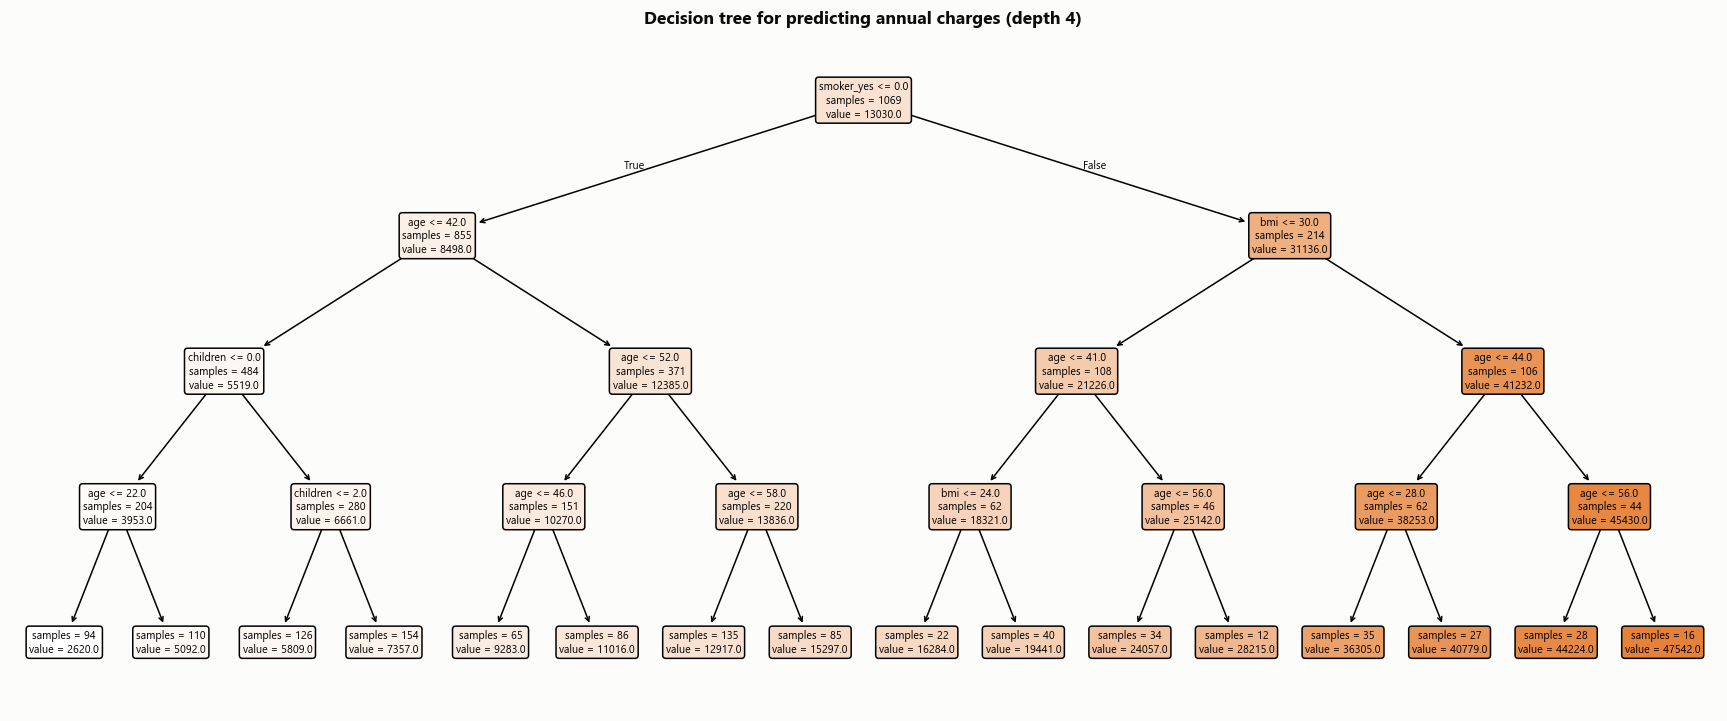

In [39]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(best_tree, feature_names=list(X.columns), filled=True, rounded=True,
          impurity=False, fontsize=7, precision=0, ax=ax)
ax.grid(False)
ax.set_title("Decision tree for predicting annual charges (depth 4)")
save_show(fig, "decision_tree.png")

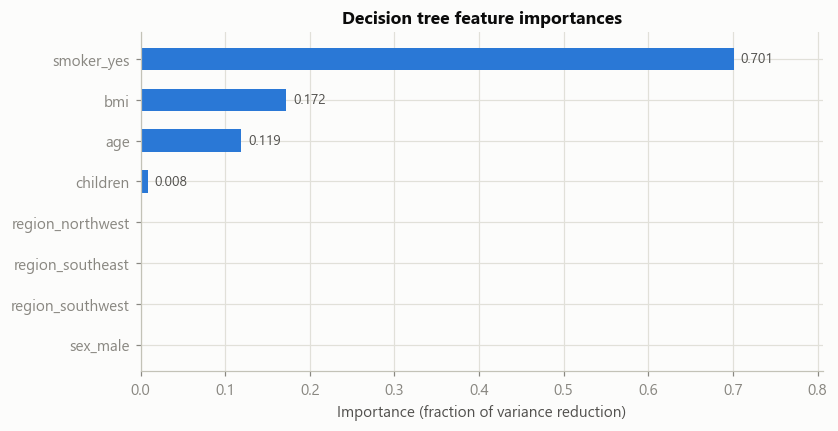

In [40]:
imp = pd.Series(best_tree.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(imp.index, imp.values, color=BLUE, height=0.55)
for i, v in enumerate(imp.values):
    if v > 0:
        ax.text(v + 0.008, i, f"{v:.3f}", va="center", fontsize=9, color=INK2)
ax.set_xlim(0, imp.max() * 1.15)
ax.set_title("Decision tree feature importances")
ax.set_xlabel("Importance (fraction of variance reduction)")
save_show(fig, "tree_feature_importance.png")

Cross validation picks depth 4 with at least 5 samples per leaf. That is deep enough to encode "does the customer smoke, is BMI over 30, how old are they" and shallow enough not to memorize the training data. The first split is smoking status, and the feature importances (smoker 0.70, bmi 0.17, age 0.12, everything else near zero) once again match the EDA.

### 6.8 Model comparison and recommendation

In [41]:
reg_summary = pd.DataFrame(reg_results).sort_values("RMSE").reset_index(drop=True)
best_name = reg_summary.loc[0, "Model"]
display_cols = {"MAE": 0, "MSE": 0, "RMSE": 0, "R2 (test)": 3, "R2 (train)": 3}
reg_summary.round(display_cols)

,Model,MAE,MSE,RMSE,R2 (test),R2 (train)
0,Decision Tree (depth=4),2621.0,18886631.0,4346.0,0.897,0.855
1,Polynomial (degree 2),2867.0,21585844.0,4646.0,0.883,0.834
2,SVR (rbf kernel),2541.0,22019125.0,4692.0,0.880,0.839
3,Polynomial (degree 3),3049.0,23719530.0,4870.0,0.871,0.847
4,Multiple Linear (all features),4177.0,35478021.0,5956.0,0.807,0.730
5,Ridge (alpha=5.62),4191.0,35673638.0,5973.0,0.806,0.730
6,Lasso (alpha=46.4),4186.0,35853382.0,5988.0,0.805,0.730
7,Polynomial (degree 4),3756.0,36697661.0,6058.0,0.800,0.867
8,SVR (linear kernel),3431.0,37116675.0,6092.0,0.798,0.702
9,Simple Linear (smoker only),5831.0,60039304.0,7749.0,0.673,0.599


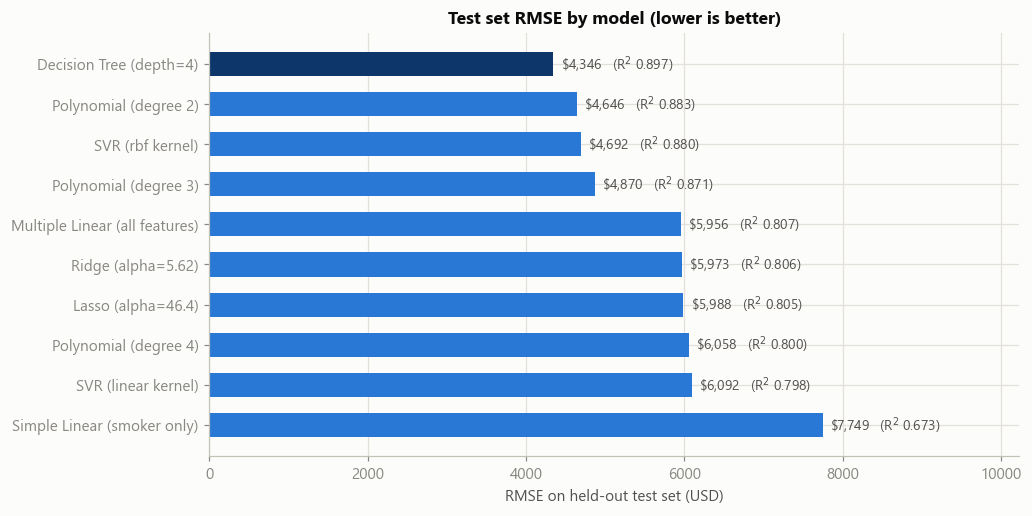

In [42]:
plot_df = reg_summary.sort_values("RMSE", ascending=False)
fig, ax = plt.subplots(figsize=(9.5, 5))
colors = ["#0d366b" if m == best_name else BLUE for m in plot_df["Model"]]
ax.barh(plot_df["Model"], plot_df["RMSE"], color=colors, height=0.6)
for i, (v, r2) in enumerate(zip(plot_df["RMSE"], plot_df["R2 (test)"])):
    ax.text(v + 90, i, rf"\${v:,.0f}   (R$^2$ {r2:.3f})", va="center", fontsize=9, color=INK2)
ax.set_xlim(0, plot_df["RMSE"].max() * 1.32)
ax.set_title("Test set RMSE by model (lower is better)")
ax.set_xlabel("RMSE on held-out test set (USD)")
save_show(fig, "regression_model_comparison.png")

### Recommendation to the stakeholder: Decision Tree (depth 4)

| Rank | Model | MAE | RMSE | R2 (test) |
|---|---|---|---|---|
| 1 | Decision Tree (depth 4) | \$2,621 | \$4,346 | 0.897 |
| 2 | Polynomial (degree 2) | \$2,867 | \$4,646 | 0.883 |
| 3 | SVR (RBF kernel) | \$2,541 | \$4,692 | 0.880 |

Why we picked the tree:

1. It is the most accurate model where it matters. It has the best RMSE and R2, and RMSE punishes exactly the kind of large pricing mistakes (an expensive customer priced as cheap) that motivated this project. A typical estimate lands within about \$2,600 of the actual cost.
2. It is easy to explain. The tree is a flowchart the pricing team and a regulator can actually read: does the customer smoke, is BMI at least 30, which age bracket, then quote. The SVR has a slightly lower MAE, but that does not make up for being a black box in a rate filing.
3. It captures the interaction naturally. The smoking and obesity effect from the EDA shows up in the first two splits without any manual feature engineering.

The runner up is the degree 2 polynomial. It is almost as accurate and produces a smooth premium curve, which would matter if the business does not want quotes grouped into the roughly 16 price bands the tree produces.

## 7. Classification: "Flag the expensive customers" (Requirement 3)

The finance team defines "expensive" as annual charges above the median. That is a fixed business rule rather than something learned from the features, so we compute it once on the cleaned data: **\$9,386.16**. By construction the classes come out balanced. `charges` itself is of course excluded from the features. We reuse the same 80/20 split, this time stratified to keep the 50/50 balance, and tune every model with 5-fold cross validation on the training set, scored on F1.

In [43]:
median_charges = df["charges"].median()
y_cls = (df["charges"] > median_charges).astype(int)
print(f"'Expensive' threshold (median annual charges): ${median_charges:,.2f}")
print(y_cls.value_counts().rename(index={0: "not expensive (<= median)", 1: "expensive (> median)"}))

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X, y_cls, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cls)
print(f"\nTrain: {Xc_train.shape[0]} | Test: {Xc_test.shape[0]} (stratified)")

'Expensive' threshold (median annual charges): $9,386.16
charges
not expensive (<= median)    669
expensive (> median)         668
Name: count, dtype: int64

Train: 1069 | Test: 268 (stratified)


In [44]:
cls_results = []
fitted_classifiers = {}

def evaluate_classifier(name, model, param_grid=None):
    # Tune with 5-fold CV on the training set, then score once on the held-out test set
    if param_grid:
        search = GridSearchCV(model, param_grid, cv=5, scoring="f1")
        search.fit(Xc_train, yc_train)
        print(f"{name} - best params: {search.best_params_}")
        model = search.best_estimator_
    else:
        model.fit(Xc_train, yc_train)
    pred = model.predict(Xc_test)
    proba = model.predict_proba(Xc_test)[:, 1]
    cls_results.append({"Model": name,
                        "Accuracy": accuracy_score(yc_test, pred),
                        "Precision": precision_score(yc_test, pred),
                        "Recall": recall_score(yc_test, pred),
                        "F1": f1_score(yc_test, pred),
                        "ROC-AUC": roc_auc_score(yc_test, proba)})
    r = cls_results[-1]
    print(f"{name}:  accuracy={r['Accuracy']:.3f}  precision={r['Precision']:.3f}  "
          f"recall={r['Recall']:.3f}  F1={r['F1']:.3f}  AUC={r['ROC-AUC']:.3f}\n")
    fitted_classifiers[name] = model
    return model

In [45]:
evaluate_classifier("Logistic Regression",
    Pipeline([("s", StandardScaler()), ("m", LogisticRegression(max_iter=5000))]),
    {"m__C": [0.01, 0.1, 1, 10]})

evaluate_classifier("K-Nearest Neighbors",
    Pipeline([("s", StandardScaler()), ("m", KNeighborsClassifier())]),
    {"m__n_neighbors": range(3, 22, 2)})

evaluate_classifier("SVM (linear)",
    Pipeline([("s", StandardScaler()),
              ("m", SVC(kernel="linear", probability=True, random_state=RANDOM_STATE))]),
    {"m__C": [0.1, 1, 10]})

evaluate_classifier("SVM (RBF)",
    Pipeline([("s", StandardScaler()),
              ("m", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))]),
    {"m__C": [1, 10, 100], "m__gamma": ["scale", 0.1]})

evaluate_classifier("Decision Tree",
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    {"max_depth": range(2, 11), "min_samples_leaf": [1, 5, 10]})

evaluate_classifier("Random Forest",
    RandomForestClassifier(random_state=RANDOM_STATE),
    {"n_estimators": [200], "max_depth": [None, 6, 10], "min_samples_leaf": [1, 5]})

evaluate_classifier("Gaussian Naive Bayes", GaussianNB());

Logistic Regression - best params: {'m__C': 1}
Logistic Regression:  accuracy=0.907  precision=0.898  recall=0.918  F1=0.908  AUC=0.953



K-Nearest Neighbors - best params: {'m__n_neighbors': 7}
K-Nearest Neighbors:  accuracy=0.903  precision=0.929  recall=0.873  F1=0.900  AUC=0.938



SVM (linear) - best params: {'m__C': 10}
SVM (linear):  accuracy=0.925  precision=0.932  recall=0.918  F1=0.925  AUC=0.954



SVM (RBF) - best params: {'m__C': 1, 'm__gamma': 0.1}
SVM (RBF):  accuracy=0.929  precision=0.946  recall=0.910  F1=0.928  AUC=0.959



Decision Tree - best params: {'max_depth': 5, 'min_samples_leaf': 10}
Decision Tree:  accuracy=0.937  precision=0.983  recall=0.888  F1=0.933  AUC=0.944



Random Forest - best params: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200}
Random Forest:  accuracy=0.937  precision=0.961  recall=0.910  F1=0.935  AUC=0.944

Gaussian Naive Bayes:  accuracy=0.757  precision=1.000  recall=0.515  F1=0.680  AUC=0.952



In [46]:
cls_summary = (pd.DataFrame(cls_results)
                 .sort_values("F1", ascending=False).reset_index(drop=True))
cls_summary.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.937,0.961,0.910,0.935,0.944
1,Decision Tree,0.937,0.983,0.888,0.933,0.944
2,SVM (RBF),0.929,0.946,0.910,0.928,0.959
3,SVM (linear),0.925,0.932,0.918,0.925,0.954
4,Logistic Regression,0.907,0.898,0.918,0.908,0.953
5,K-Nearest Neighbors,0.903,0.929,0.873,0.900,0.938
6,Gaussian Naive Bayes,0.757,1.000,0.515,0.680,0.952


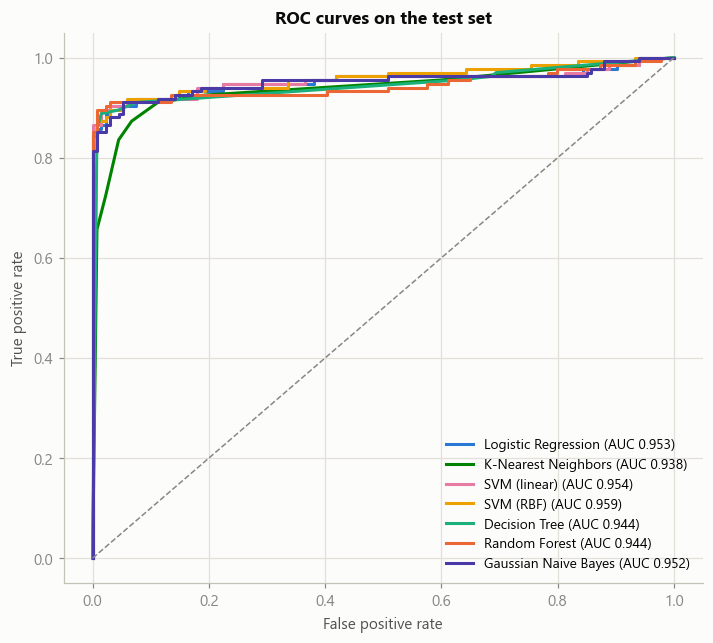

In [47]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))
for (name, model), color in zip(fitted_classifiers.items(), CATEGORICAL):
    proba = model.predict_proba(Xc_test)[:, 1]
    fpr, tpr, _ = roc_curve(yc_test, proba)
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f"{name} (AUC {roc_auc_score(yc_test, proba):.3f})")
ax.plot([0, 1], [0, 1], color=MUTED, lw=1, ls="--")
ax.set_title("ROC curves on the test set")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend(frameon=False, fontsize=9, loc="lower right")
save_show(fig, "classification_roc.png")

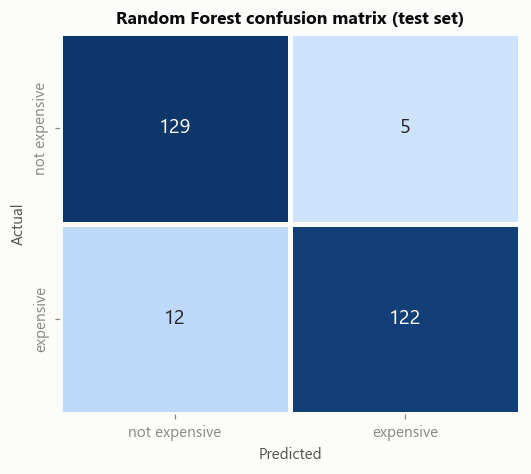

Of 134 truly expensive customers, 122 were flagged (91.0% recall);
12 slipped through as false negatives - the costly error type for HealthGuard.


In [48]:
best_cls_name = "Random Forest"
best_cls = fitted_classifiers[best_cls_name]
cm = confusion_matrix(yc_test, best_cls.predict(Xc_test))

fig, ax = plt.subplots(figsize=(5.4, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap=SEQ_BLUES, cbar=False,
            linewidths=2, linecolor=SURFACE,
            xticklabels=["not expensive", "expensive"],
            yticklabels=["not expensive", "expensive"],
            annot_kws={"fontsize": 13}, ax=ax)
ax.grid(False)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"{best_cls_name} confusion matrix (test set)")
save_show(fig, "confusion_matrix.png")

tn, fp, fn, tp = cm.ravel()
print(f"Of {tp + fn} truly expensive customers, {tp} were flagged ({tp / (tp + fn):.1%} recall);")
print(f"{fn} slipped through as false negatives - the costly error type for HealthGuard.")

### Classification recommendation: Random Forest

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Random Forest | 0.937 | 0.961 | 0.910 | 0.935 | 0.944 |
| Decision Tree (depth 5) | 0.937 | 0.983 | 0.888 | 0.933 | 0.944 |
| SVM (RBF) | 0.929 | 0.946 | 0.910 | 0.928 | 0.959 |

- The Random Forest has the best F1 (0.935) and the best balance between precision (0.961) and recall (0.910), so it takes the recommendation.
- For HealthGuard the expensive mistake is the false negative: an expensive customer priced as cheap is a direct loss, while a false positive only risks quoting a bit high. That asymmetry is why we prefer the Forest over the single decision tree (recall 0.910 against 0.888) even though their accuracy is identical.
- If management wants to catch even more of the expensive customers, the Forest's probability threshold can be lowered below 0.5. That trades some precision for recall and needs no retraining.
- Gaussian Naive Bayes shows why accuracy alone is not enough. Its precision is perfect, but it misses about half of the expensive customers (recall 0.515), which is the same failure mode the company already suffers from.

## 8. Final recommendation to Ms. Nabil

**What drives cost.** Three factors, in order: smoking (smokers cost about 3.8 times more, \$32,050 against \$8,441), age (roughly \$250 to \$280 per year), and BMI, whose effect multiplies with smoking (obese smokers average \$41,693, about 4.7 times obese non-smokers). Sex, region and children barely matter, and Lasso regression discarded sex entirely.

**Pricing tool (Requirement 2).** We recommend the depth 4 decision tree: R2 of 0.897, a typical error around \$2,600, and it can be read as a plain set of pricing rules, which should help with regulatory review. The degree 2 polynomial is a good alternative if smooth quotes are required.

**Expensive customer flag (Requirement 3).** We recommend the random forest: 93.7% accuracy on the test set, and it catches 91% of the expensive customers that the current tables misprice. The threshold can be lowered if a wider net is wanted.

**Limitations.**
- 1,337 customers is a small sample. The models should be retrained and validated on HealthGuard's own book before production use.
- The data contains no claims history, chronic conditions or medications, which are the strongest actuarial signals an insurer usually has.
- Smoking status is self reported and tends to be under reported in practice. Verification may be worth the cost on large policies.
- Using sex (or proxies for it) in pricing is restricted in some jurisdictions. The models barely use it, so dropping it costs almost nothing.
- Charges cover a single year, so multi year risk cannot be priced from this data yet.

---

### Appendix: where each pandas wrangling technique appears

| Technique | Where |
|---|---|
| Reading with encoding, profiling (`head`, `shape`, `info`, `describe`, `value_counts`) | Section 2 |
| Missing value handling | Section 3.1 |
| Dropping duplicates | Section 3.2 |
| Replacing and standardizing values (`str.strip`, `str.lower`, `map`) | Sections 3.3 and 3.6 |
| Validity filtering (`between`, boolean masks) | Section 3.4 |
| Type conversion (`astype("category")`) | Section 3.5 |
| Creating columns (`pd.cut`, boolean logic, `map`) | Section 3.6 |
| Selecting (`[]`, `loc`), filtering, sorting (`sort_values`) | Section 3.7 |
| Grouping and aggregating (`groupby`, `agg`, `mean`, `unstack`) | Sections 3.7 and 4 |
| Merging (`merge`) and concatenating (`concat`) | Section 3.7 |
| Applying functions (`apply` row-wise in 3.7, `map` elementwise in 3.6) | Sections 3.6 and 3.7 |
| Renaming (`rename`) | Section 3.7 |
| Dropping columns (`drop`), encoding (`get_dummies`) | Section 5 |
| Resampling | Not applicable. Resampling needs a datetime axis, and this dataset has no time dimension (one row per customer), so we note it here instead of forcing it. |